In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/carvana-image-masking-challenge/train_masks.zip
/kaggle/input/carvana-image-masking-challenge/29bb3ece3180_11.jpg
/kaggle/input/carvana-image-masking-challenge/train_masks.csv.zip
/kaggle/input/carvana-image-masking-challenge/train.zip
/kaggle/input/carvana-image-masking-challenge/metadata.csv.zip
/kaggle/input/carvana-image-masking-challenge/sample_submission.csv.zip
/kaggle/input/carvana-image-masking-challenge/test.zip
/kaggle/input/carvana-image-masking-challenge/test_hq.zip
/kaggle/input/carvana-image-masking-challenge/train_hq.zip


### U-Net: Segmentation from Scratch with PyTorch
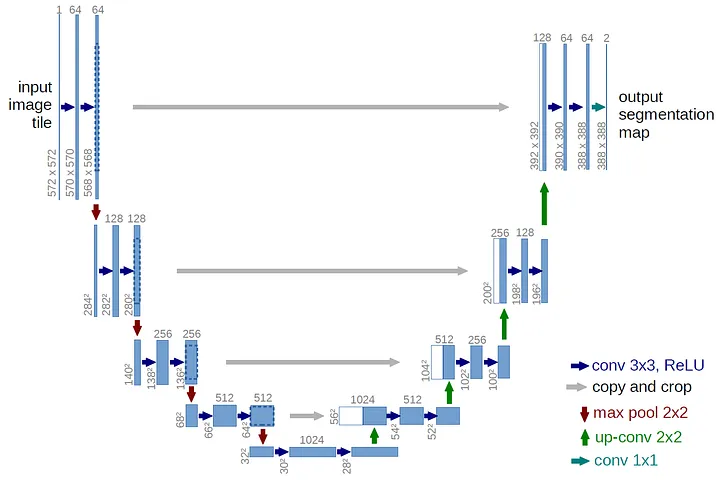
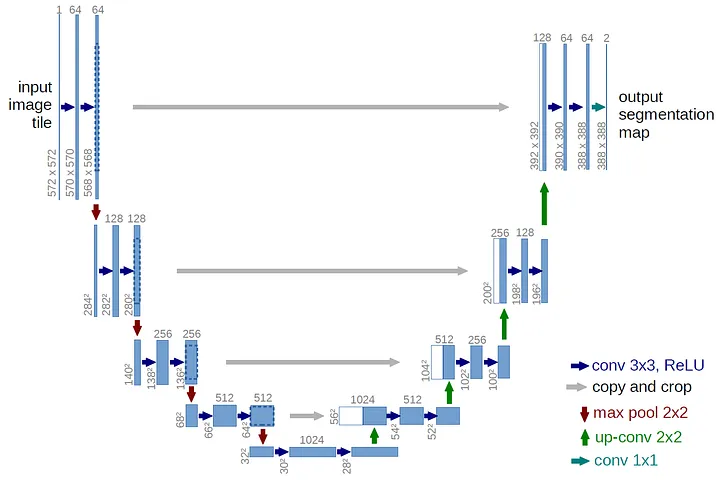

Segmentation is the process of dividing an image into multiple segments or regions to simplify its representation and make it easier to analyze.

In [2]:
import copy
import os
import random
import shutil
import zipfile
from math import atan2, cos, sin, sqrt, pi, log

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from PIL import Image
from numpy import linalg as LA
from torch import optim, nn
from torch.utils.data import DataLoader, random_split
from torch.utils.data.dataset import Dataset
from torchvision import transforms
from tqdm import tqdm

Double Convolution

In [3]:
class DoubleConv(nn.Module):
    def __init__(self,in_channels,out_channels):
        super().__init__()
        self.conv_op = nn.Sequential(
            nn.Conv2d(in_channels,out_channels,kernel_size=3,padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels,out_channels,kernel_size=3,padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self,x):
        return self.conv_op(x)

Downsampling Part

In [4]:
class DownSample(nn.Module):
    def __init__(self,in_channels,out_channels):
        super().__init__()
        self.conv = DoubleConv(in_channels,out_channels)
        self.pool = nn.MaxPool2d(kernel_size=2,stride=2)
    def forward(self,x):
        down = self.conv(x)
        p = self.pool(down)

        return down,p

Here downsample return two value down and p because the convolutioned tensor is later on concatenated with an upsample tensor with its own dimension

In [5]:
class UpSample(nn.Module):
    def __init__(self,in_channels,out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels,in_channels//2,kernel_size=2,stride=2)
        self.conv = DoubleConv(in_channels,out_channels)

    def forward(self,x1,x2):
        x1 = self.up(x1)
        x = torch.cat([x1,x2],1)
        return self.conv(x)
        

UNet Architecture

In [6]:
class UNet(nn.Module):
    def __init__(self,in_channels,num_classes):
        super().__init__()
        self.down_convolution_1 = DownSample(in_channels,64)
        self.down_convolution_2 = DownSample(64,128)
        self.down_convolution_3 = DownSample(128, 256)
        self.down_convolution_4 = DownSample(256, 512)

        self.bottle_neck = DoubleConv(512,1024)

        self.up_convolution_1 = UpSample(1024, 512)
        self.up_convolution_2 = UpSample(512, 256)
        self.up_convolution_3 = UpSample(256, 128)
        self.up_convolution_4 = UpSample(128, 64)

        self.out = nn.Conv2d(in_channels=64,out_channels=num_classes,kernel_size=1)

    def forward(self,x):
        down_1,p1 = self.down_convolution_1(x)
        down_2,p2 = self.down_convolution_2(p1)
        down_3,p3 = self.down_convolution_3(p2)
        down_4,p4 = self.down_convolution_4(p3)

        b = self.bottle_neck(p4)

        up_1 = self.up_convolution_1(b, down_4)
        up_2 = self.up_convolution_2(up_1, down_3)
        up_3 = self.up_convolution_3(up_2, down_2)
        up_4 = self.up_convolution_4(up_3, down_1)

        out = self.out(up_4)
        return out

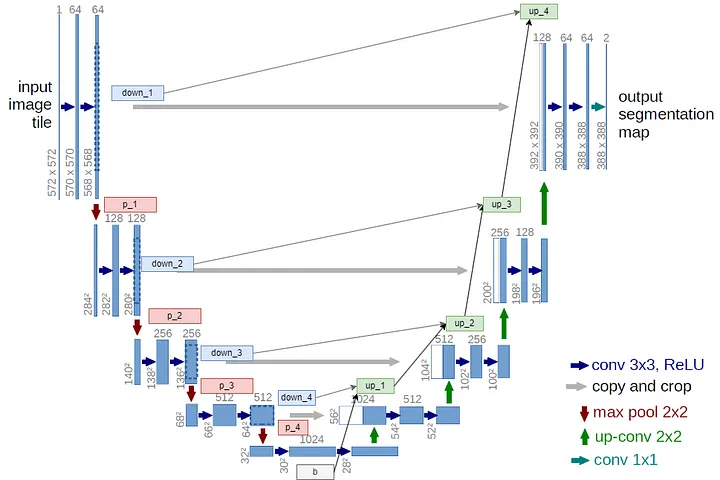
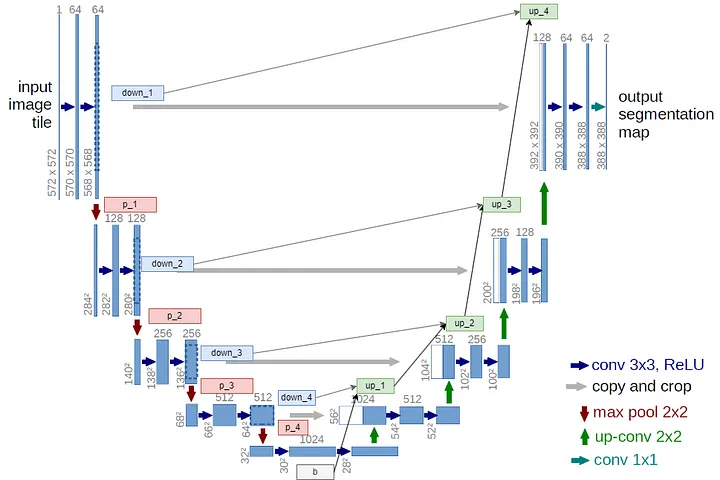

In [7]:
input_image = torch.rand((1,3,512,512))
model = UNet(3,10)
output = model(input_image)
print(output.size())

torch.Size([1, 10, 512, 512])


In [8]:
class CarvanaDataset(Dataset):
    def __init__(self,root_path,limit=None):
        self.root_path = root_path
        self.limit = limit
        self.images = sorted([root_path + "/train/" + i for i in os.listdir(root_path + "/train/")])[:self.limit]
        self.masks = sorted([root_path + "/train_masks/" + i for i in os.listdir(root_path + "/train_masks/")])[:self.limit]
        self.transform = transforms.Compose([
            transforms.Resize((512,512)),
            transforms.ToTensor()
        ])

        if self.limit is None:
            self.limit = len(self.images)

    def __len__(self):
        return min(len(self.images),self.limit)

    def __getitem__(self,index):
        img = Image.open(self.images[index]).convert("RGB")
        mask = Image.open(self.masks[index]).convert("L")
        return self.transform(img),self.transform(mask)


In [9]:
print(os.listdir("../input/carvana-image-masking-challenge/"))

DATASET_DIR = '../input/carvana-image-masking-challenge/'
WORKING_DIR = '/kaggle/working/'

['train_masks.zip', '29bb3ece3180_11.jpg', 'train_masks.csv.zip', 'train.zip', 'metadata.csv.zip', 'sample_submission.csv.zip', 'test.zip', 'test_hq.zip', 'train_hq.zip']


In [10]:
if len(os.listdir(WORKING_DIR)) <= 1:

    with zipfile.ZipFile(DATASET_DIR + 'train.zip', 'r') as zip_file:
        zip_file.extractall(WORKING_DIR)

    with zipfile.ZipFile(DATASET_DIR + 'train_masks.zip', 'r') as zip_file:
        zip_file.extractall(WORKING_DIR)
    
    print(
        len(os.listdir(WORKING_DIR + 'train')),
        len(os.listdir(WORKING_DIR + 'train_masks'))
    )

5088 5088


In [11]:
train_dataset = CarvanaDataset(WORKING_DIR,limit=1000)

generator = torch.Generator().manual_seed(25)

In [12]:
train_dataset, test_dataset = random_split(train_dataset, [0.8, 0.2], generator=generator)

In [13]:
test_dataset, val_dataset = random_split(test_dataset, [0.5, 0.5], generator=generator)

In [14]:
device = "cuda" if torch.cuda.is_available() else "cpu"

if device == "cuda":
    num_workers = torch.cuda.device_count() * 4

In [15]:
LEARNING_RATE = 3e-4
BATCH_SIZE = 8

train_dataloader = DataLoader(dataset=train_dataset,
                              num_workers=num_workers, pin_memory=False,
                              batch_size=BATCH_SIZE,
                              shuffle=True)
val_dataloader = DataLoader(dataset=val_dataset,
                            num_workers=num_workers, pin_memory=False,
                            batch_size=BATCH_SIZE,
                            shuffle=True)

test_dataloader = DataLoader(dataset=test_dataset,
                            num_workers=num_workers, pin_memory=False,
                            batch_size=BATCH_SIZE,
                            shuffle=True)

model = UNet(in_channels=3, num_classes=1).to(device)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)
criterion = nn.BCEWithLogitsLoss()

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


#### DICE Metric
The DICE metric provides a measure of the similarity between two sets, in this case, the predicted segmentation and the ground truth segmentation. It calculates the overlap between the two sets, taking into account both the false positives and false negatives.

Mathematically, the DICE score is defined as:

DICE score = 2 * |A ∩ B| / (|A| + |B|)

And can be understood as:
Dice score = 2 * (number of common elements) / (number of elements in set A + number of elements in set B)

In [16]:
def dice_coefficient(prediction, target, epsilon=1e-07):
    prediction_copy = prediction.clone()

    prediction_copy[prediction_copy < 0] = 0
    prediction_copy[prediction_copy > 0] = 1

    intersection = abs(torch.sum(prediction_copy * target))
    union = abs(torch.sum(prediction_copy) + torch.sum(target))
    dice = (2. * intersection + epsilon) / (union + epsilon)
    
    return dice

In [17]:
torch.cuda.empty_cache()

In [18]:
EPOCHS = 10

train_losses = []
train_dcs = []
val_losses = []
val_dcs = []

for epoch in tqdm(range(EPOCHS)):
    model.train()
    train_running_loss = 0
    train_running_dc = 0
    
    for idx, img_mask in enumerate(tqdm(train_dataloader, position=0, leave=True)):
        img = img_mask[0].float().to(device)
        mask = img_mask[1].float().to(device)
        
        y_pred = model(img)
        optimizer.zero_grad()
        
        dc = dice_coefficient(y_pred, mask)
        loss = criterion(y_pred, mask)
        
        train_running_loss += loss.item()
        train_running_dc += dc.item()

        loss.backward()
        optimizer.step()

    train_loss = train_running_loss / (idx + 1)
    train_dc = train_running_dc / (idx + 1)
    
    train_losses.append(train_loss)
    train_dcs.append(train_dc)

    model.eval()
    val_running_loss = 0
    val_running_dc = 0
    
    with torch.no_grad():
        for idx, img_mask in enumerate(tqdm(val_dataloader, position=0, leave=True)):
            img = img_mask[0].float().to(device)
            mask = img_mask[1].float().to(device)

            y_pred = model(img)
            loss = criterion(y_pred, mask)
            dc = dice_coefficient(y_pred, mask)
            
            val_running_loss += loss.item()
            val_running_dc += dc.item()

        val_loss = val_running_loss / (idx + 1)
        val_dc = val_running_dc / (idx + 1)
    
    val_losses.append(val_loss)
    val_dcs.append(val_dc)

    print("-" * 30)
    print(f"Training Loss EPOCH {epoch + 1}: {train_loss:.4f}")
    print(f"Training DICE EPOCH {epoch + 1}: {train_dc:.4f}")
    print("\n")
    print(f"Validation Loss EPOCH {epoch + 1}: {val_loss:.4f}")
    print(f"Validation DICE EPOCH {epoch + 1}: {val_dc:.4f}")
    print("-" * 30)

# Saving the model
torch.save(model.state_dict(), 'my_checkpoint.pth')

 10%|█         | 1/10 [02:56<26:30, 176.69s/it]

------------------------------
Training Loss EPOCH 1: 0.4369
Training DICE EPOCH 1: 0.3163


Validation Loss EPOCH 1: 0.2939
Validation DICE EPOCH 1: 0.6978
------------------------------


 20%|██        | 2/10 [06:14<25:12, 189.09s/it]

------------------------------
Training Loss EPOCH 2: 0.2706
Training DICE EPOCH 2: 0.7018


Validation Loss EPOCH 2: 0.1502
Validation DICE EPOCH 2: 0.8132
------------------------------


 30%|███       | 3/10 [09:36<22:44, 194.92s/it]

...

------------------------------
Training Loss EPOCH 8: 0.0269
Training DICE EPOCH 8: 0.9748


Validation Loss EPOCH 8: 0.0263
Validation DICE EPOCH 8: 0.9737
------------------------------


 90%|█████████ | 9/10 [29:47<03:21, 201.70s/it]

------------------------------
Training Loss EPOCH 9: 0.0224
Training DICE EPOCH 9: 0.9790


Validation Loss EPOCH 9: 0.0202
Validation DICE EPOCH 9: 0.9805
------------------------------


100%|██████████| 10/10 [33:10<00:00, 199.02s/it]


------------------------------
Training Loss EPOCH 10: 0.0190
Training DICE EPOCH 10: 0.9822


Validation Loss EPOCH 10: 0.0178
Validation DICE EPOCH 10: 0.9832
------------------------------


/tmp/ipykernel_19/3950988869.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


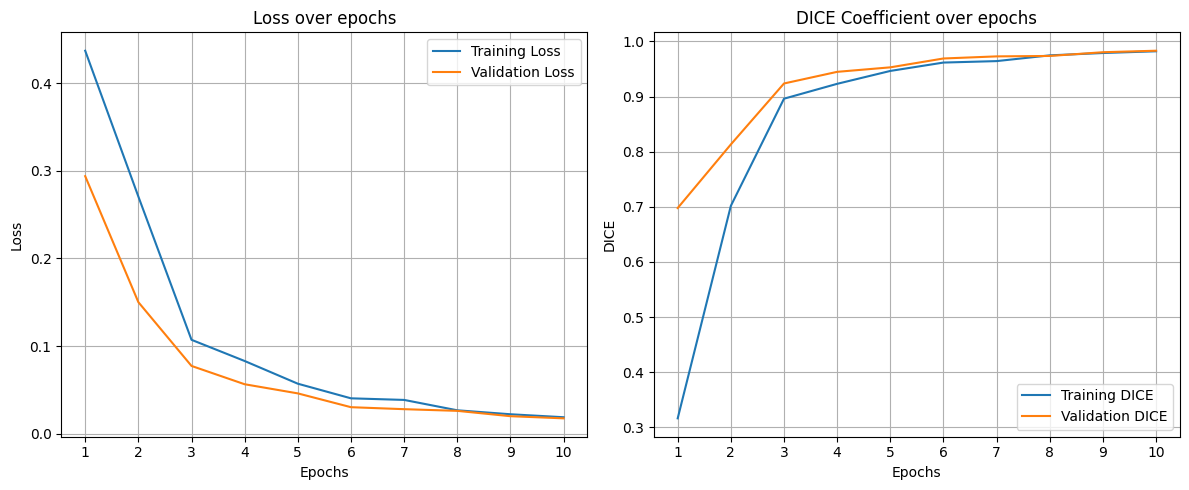

In [19]:
epochs_list = list(range(1, EPOCHS + 1))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_list, train_losses, label='Training Loss')
plt.plot(epochs_list, val_losses, label='Validation Loss')
plt.xticks(ticks=list(range(1, EPOCHS + 1, 1))) 
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid()
plt.tight_layout()

plt.legend()


plt.subplot(1, 2, 2)
plt.plot(epochs_list, train_dcs, label='Training DICE')
plt.plot(epochs_list, val_dcs, label='Validation DICE')
plt.xticks(ticks=list(range(1, EPOCHS + 1, 1)))  
plt.title('DICE Coefficient over epochs')
plt.xlabel('Epochs')
plt.ylabel('DICE')
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

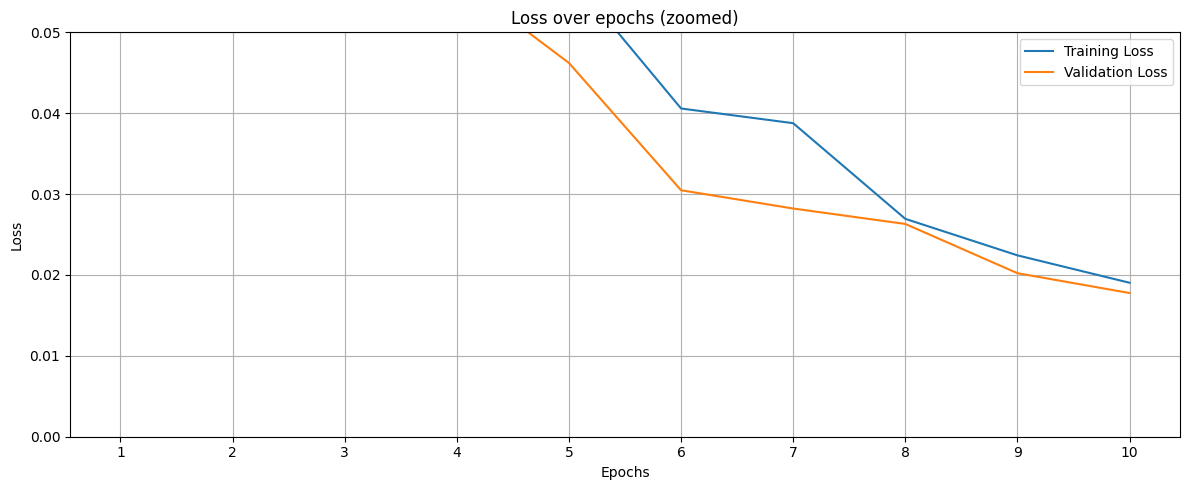

In [20]:
epochs_list = list(range(1, EPOCHS + 1))

plt.figure(figsize=(12, 5))
plt.plot(epochs_list, train_losses, label='Training Loss')
plt.plot(epochs_list, val_losses, label='Validation Loss')
plt.xticks(ticks=list(range(1, EPOCHS + 1, 1))) 
plt.ylim(0, 0.05)
plt.title('Loss over epochs (zoomed)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid()
plt.tight_layout()

plt.legend()
plt.show()

In [21]:
model_pth = '/kaggle/working/my_checkpoint.pth'
trained_model = UNet(in_channels=3, num_classes=1).to(device)
trained_model.load_state_dict(torch.load(model_pth, map_location=torch.device(device)))

<All keys matched successfully>

In [22]:
test_running_loss = 0
test_running_dc = 0

with torch.no_grad():
    for idx, img_mask in enumerate(tqdm(test_dataloader, position=0, leave=True)):
        img = img_mask[0].float().to(device)
        mask = img_mask[1].float().to(device)

        y_pred = trained_model(img)
        loss = criterion(y_pred, mask)
        dc = dice_coefficient(y_pred, mask)

        test_running_loss += loss.item()
        test_running_dc += dc.item()

    test_loss = test_running_loss / (idx + 1)
    test_dc = test_running_dc / (idx + 1)

100%|██████████| 13/13 [00:10<00:00,  1.19it/s]


In [23]:
def random_images_inference(image_tensors, mask_tensors, image_paths, model_pth, device):
    model = UNet(in_channels=3, num_classes=1).to(device)
    model.load_state_dict(torch.load(model_pth, map_location=torch.device(device)))

    transform = transforms.Compose([
        transforms.Resize((512, 512))
    ])

    # Iterate for the images, masks and paths
    for image_pth, mask_pth, image_paths in zip(image_tensors, mask_tensors, image_paths):
        # Load the image
        img = transform(image_pth)
        
        # Predict the imagen with the model
        pred_mask = model(img.unsqueeze(0))
        pred_mask = pred_mask.squeeze(0).permute(1,2,0)
        
        # Load the mask to compare
        mask = transform(mask_pth).permute(1, 2, 0).to(device)
        
        print(f"Image: {os.path.basename(image_paths)}, DICE coefficient: {round(float(dice_coefficient(pred_mask, mask)),5)}")
        
        # Show the images
        img = img.cpu().detach().permute(1, 2, 0)
        pred_mask = pred_mask.cpu().detach()
        pred_mask[pred_mask < 0] = 0
        pred_mask[pred_mask > 0] = 1
        
        plt.figure(figsize=(15, 16))
        plt.subplot(131), plt.imshow(img), plt.title("original")
        plt.subplot(132), plt.imshow(pred_mask, cmap="gray"), plt.title("predicted")
        plt.subplot(133), plt.imshow(mask, cmap="gray"), plt.title("mask")
        plt.show()